## 1 ----------------------------------------

Generamos u(t)

In [38]:
# Importaciones, asi no las corro en celditas individuales...
import numpy as np
import matplotlib.pyplot as plt


In [39]:
def u(t):
    return np.where(t>0, 1, 0)

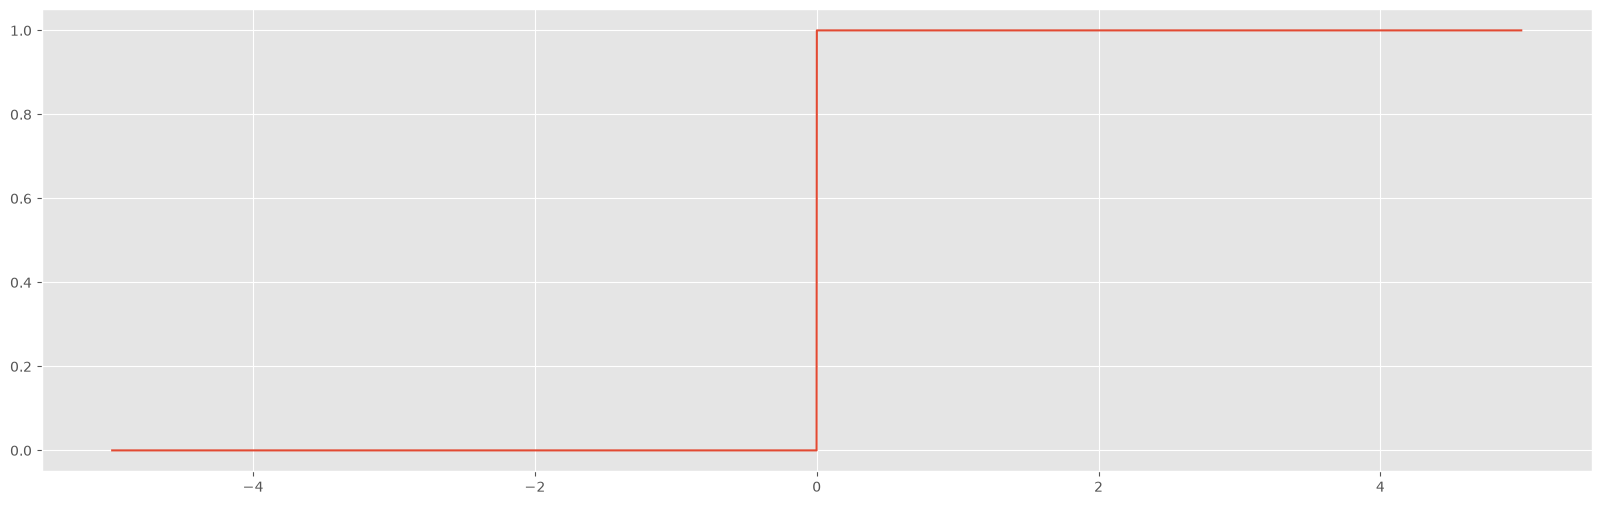

In [ ]:
# Probamos
t = np.linspace (-5,5,5000)

plt.figure(figsize=(20,3))
plt.style.use("ggplot")
fa = u(t)
plt.plot(t,fa)
plt.show()

In [41]:
def h(t,alfa):
    return np.e**(-alfa*t)
    

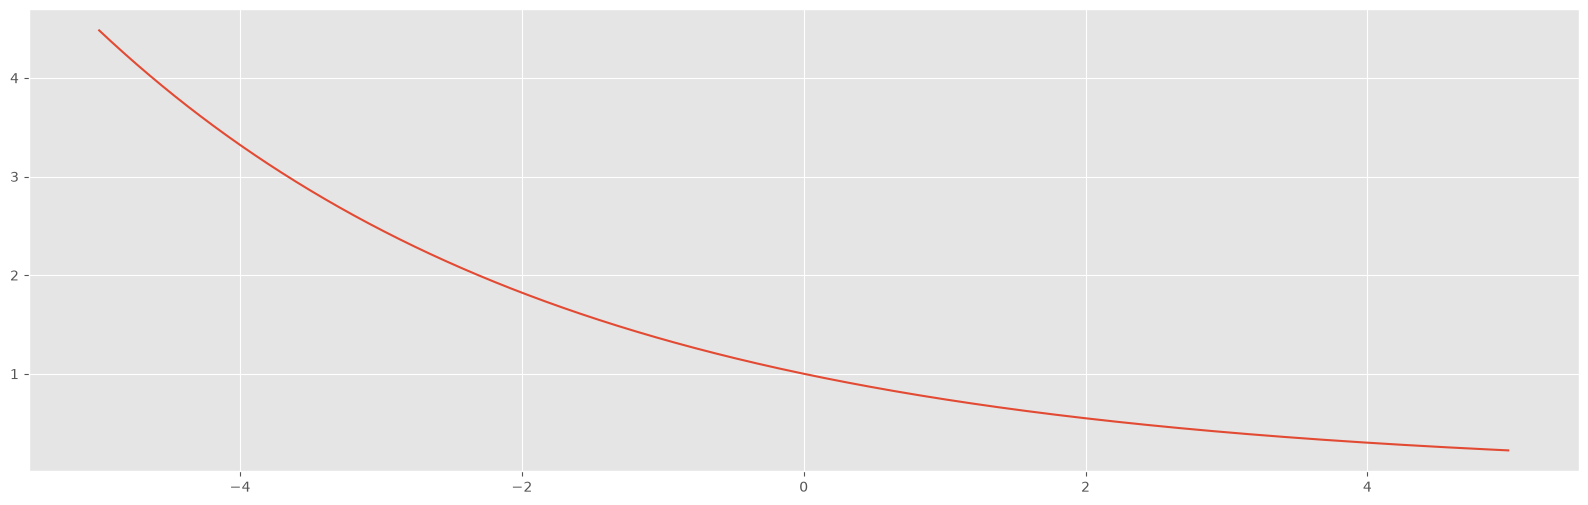

In [ ]:
# probamos h(t)
plt.figure(figsize=(20,3))
plt.style.use("ggplot")
fb = h(t,0.3)
plt.plot(t,fb)

In [43]:
def convol(fa,fb):
    fb_inv = fb[::-1] # invertimos

    l_resultado = len(fa)+len(fb)-1
    res = np.zeros(l_resultado)

    ceros = len(fb)-1
    fa_ext = np.concatenate((np.zeros(ceros),fa,np.zeros(ceros))) # agregamos ceros para poder desplazar

    for i in range(l_resultado):
        ventana = fa_ext[i:i+len(fb)] # tomamos lo que se solapa
        res[i] = np.sum(ventana*fb_inv)

    return res

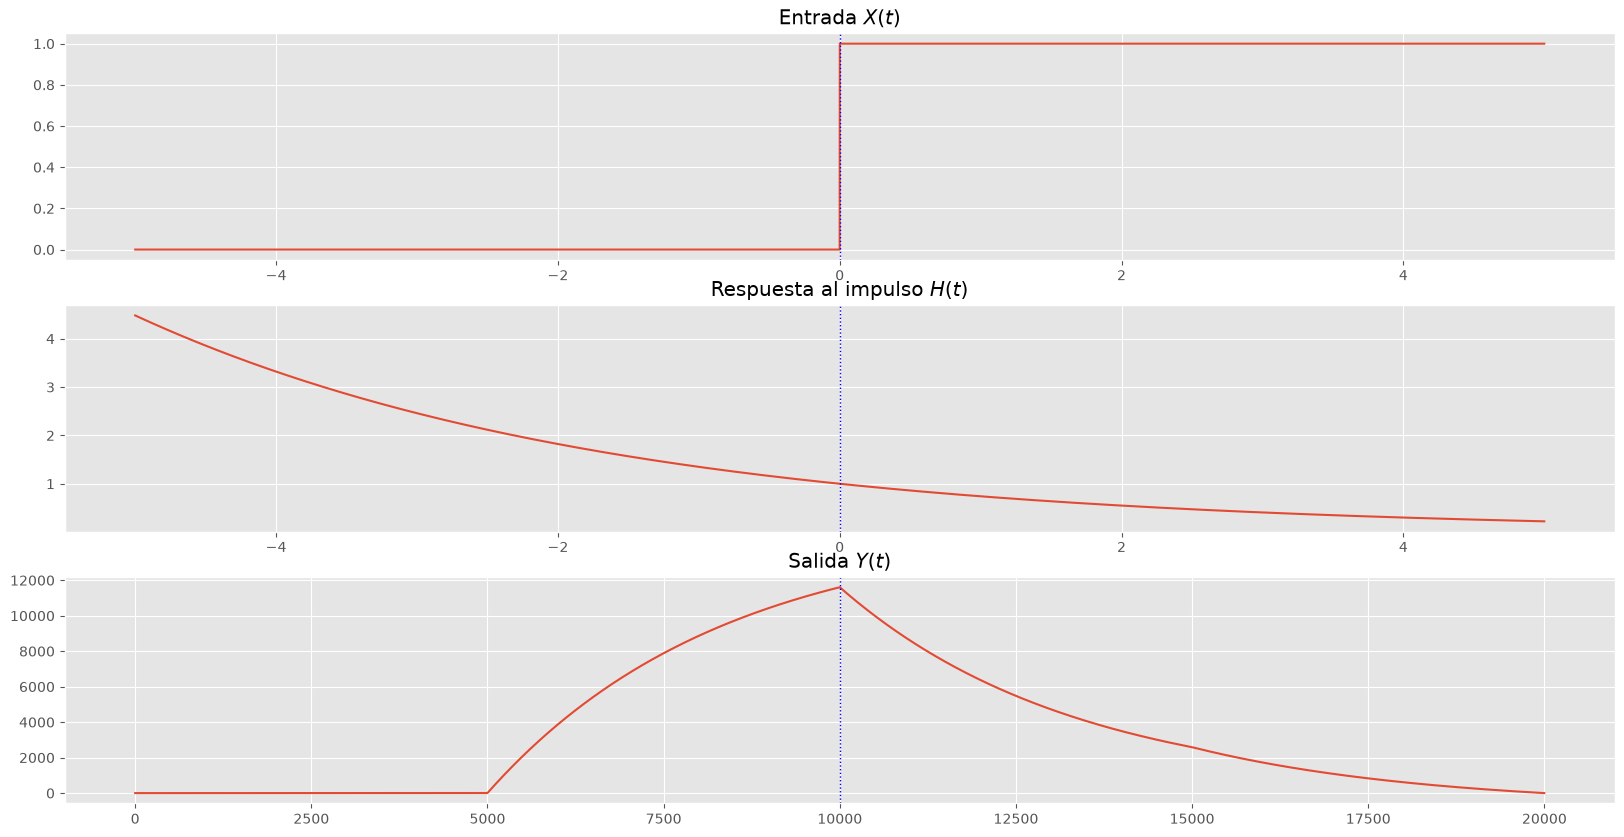

In [107]:
# probamos la conv
yt = convol(fa,fb)

fig,eje = plt.subplots(3,1,figsize=(20,10))

eje[0].plot(t,fa)
eje[0].set_title(r"Entrada $X(t)$")

eje[1].plot(t,fb)
eje[1].set_title(r"Respuesta al impulso $H(t)$")

eje[2].plot(yt)
eje[2].set_title(r"Salida $Y(t)$")

#eje vertical para todos

eje[0].axvline(0, color="blue", linewidth=1, linestyle=":")
eje[1].axvline(0, color="blue", linewidth=1, linestyle=":")
eje[2].axvline(10000, color="blue", linewidth=1, linestyle=":")

plt.show()

[0.         0.         0.         ... 0.22326409 0.22319712 0.22313016]


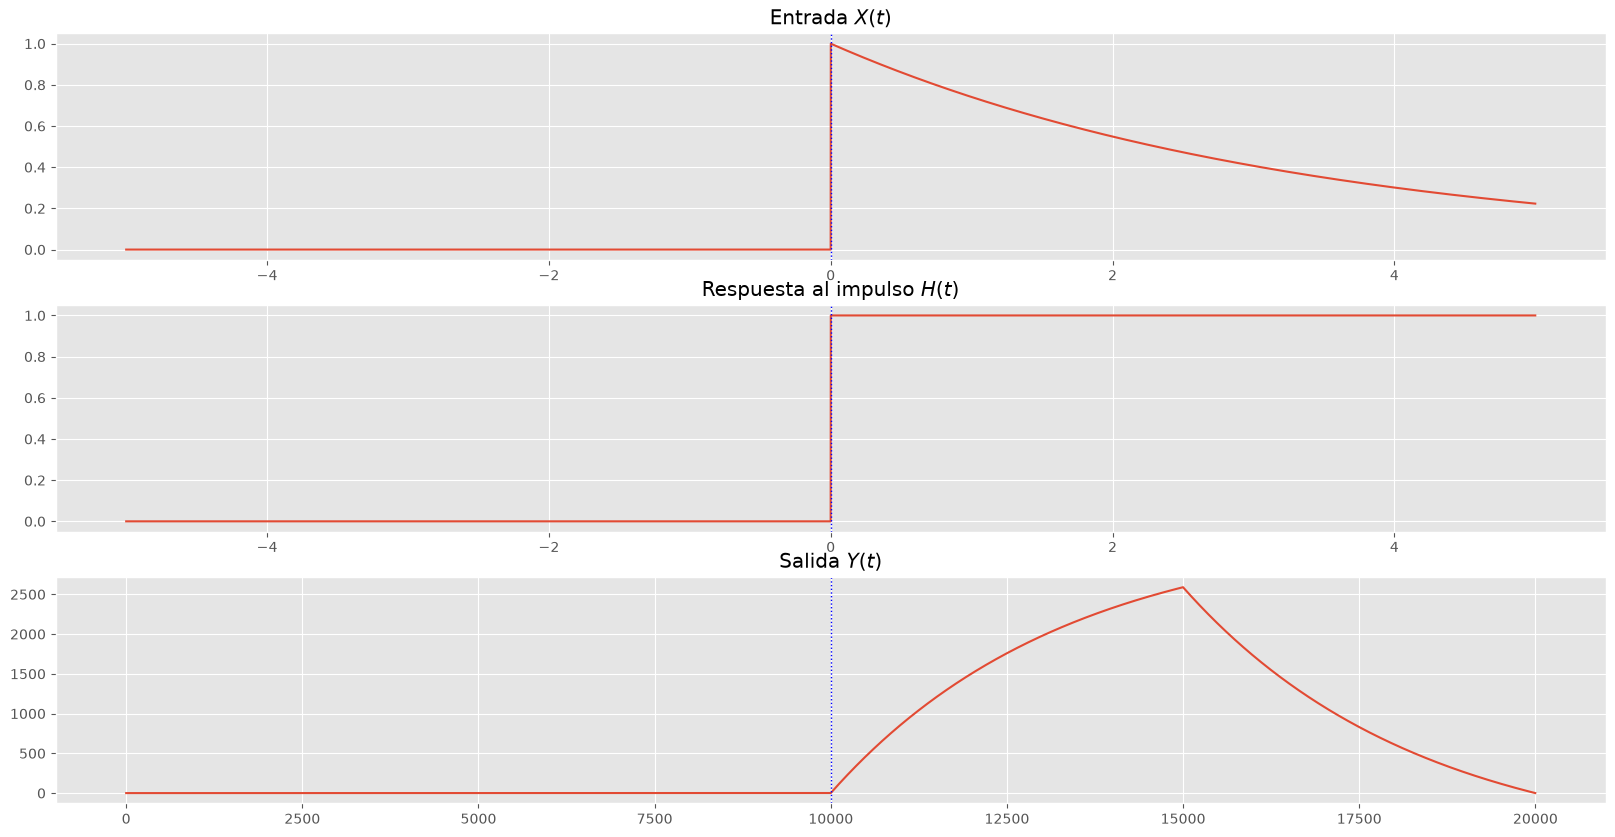

In [108]:
# Ahora pero cambiando x(t)
t=np.linspace(-5,5,10000)
x2 = h(t,0.3)*u(t)
h2 = u(t)
yt = convol(x2,h2)
print(x2)
fig,eje = plt.subplots(3,1,figsize=(20,10))

eje[0].plot(t,x2)
eje[0].set_title(r"Entrada $X(t)$")

eje[1].plot(t,h2)
eje[1].set_title(r"Respuesta al impulso $H(t)$")

eje[2].plot(yt)
eje[2].set_title(r"Salida $Y(t)$")

#eje vertical pa' todos
eje[0].axvline(0, color="blue", linewidth=1, linestyle=":")
eje[1].axvline(0, color="blue", linewidth=1, linestyle=":")
eje[2].axvline(10000, color="blue", linewidth=1, linestyle=":")
plt.show()

Como que se ve igual pero desplazada, y arranca del 0. De la otra manera no arranca del 0.

Lo hacemos con el primer ejemplo pero paso a paso. Armo 4 posiciones distintas.

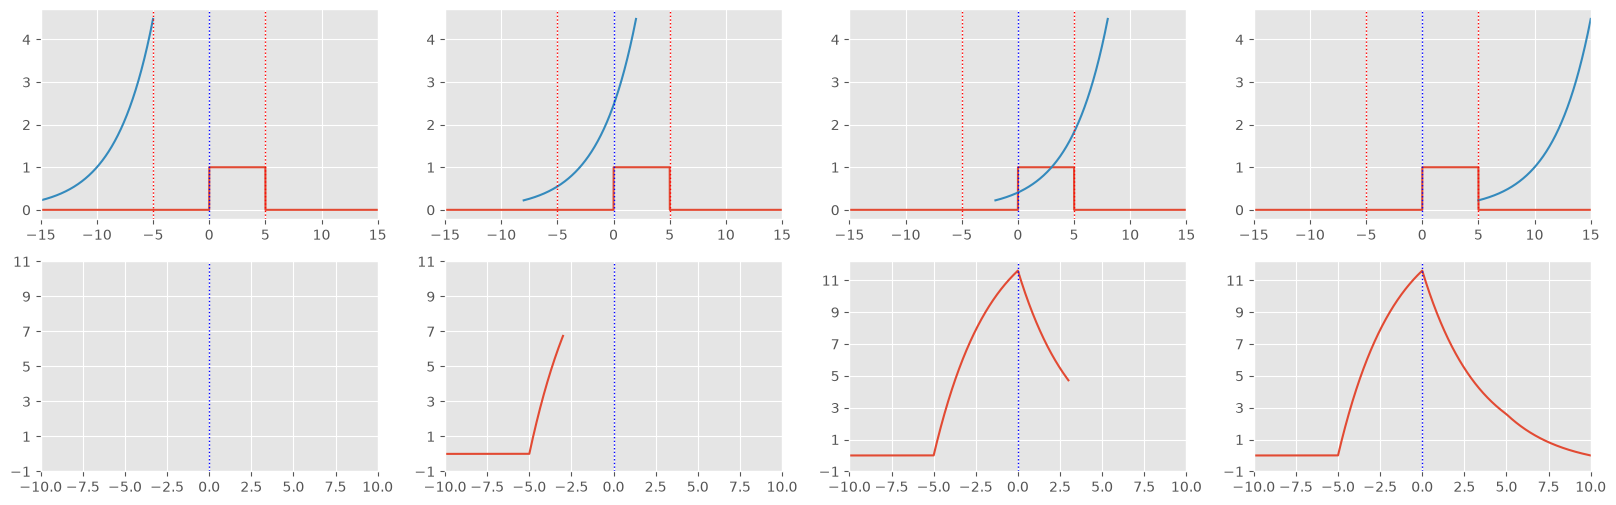

In [118]:
t = np.linspace(-5,5,10000)
fa = u(t)
fb = h(t,0.3)

#desde aca es lo mismo que tengo en la funcion "desarmado", preparar las señales para la convolucion
l_resultado = len(fa)+len(fb)-1
res = np.zeros(l_resultado)

fb_inv = fb[::-1] # invertimos

ceros = len(fb)-1
fa_ext = np.concatenate((np.zeros(ceros),fa,np.zeros(ceros))) # agregamos ceros para poder desplazar

dt = t[1]-t[0]
t_ext = np.arange(len(fa_ext))*dt + (t[0]-ceros*dt) #tengo que hacer esto para alargar el eje de tiempo y que se vea en el
t_res = np.arange(l_resultado)*dt + 2*t[0] # eje de la convolucion, resultado


# hacemos la convolucion
for i in range(l_resultado):
    ventana = fa_ext[i:i+len(fb)] # tomamos lo que se solapa
    res[i] = np.sum(ventana*fb_inv)*dt


## de acá podemos plotear todos los a de cada grafiquito
fig,eje=plt.subplots(2,4,figsize=(20,6))

for i in range(0,4):
    eje[0][i].plot(t_ext,fa_ext)

# mis 4 instantes. por porcentaje asi lo podemos correr facil
i1 = 0 # 0%
i2 = int((l_resultado-1)*0.35) # 35%
i3 = int((l_resultado-1)*0.65) # 65%
i4 = l_resultado-1 # 100%


# arranca completamente afuera
t_fb1 = t_ext[i1:i1+len(fb)]
eje[0][0].plot(t_fb1,fb_inv)
eje[0][0].set_xlim(-15,15)
eje[1][0].plot(t_res[:i1+1],res[:i1+1])
eje[1][0].set_xlim(-10,10)


# 25% del recorrido
t_fb2 = t_ext[i2:i2+len(fb)]
eje[0][1].plot(t_fb2,fb_inv)
eje[0][1].set_xlim(-15,15)
eje[1][1].plot(t_res[:i2+1],res[:i2+1]) # muestra todo lo que ya calculamos
eje[1][1].set_xlim(-10,10)


# 65% del recorrido
t_fb3 = t_ext[i3:i3+len(fb)]
eje[0][2].plot(t_fb3,fb_inv)
eje[0][2].set_xlim(-15,15)
eje[1][2].plot(t_res[:i3+1],res[:i3+1])
eje[1][2].set_xlim(-10,10)


# termina completamente afuera
t_fb4 = t_ext[i4:i4+len(fb)]
eje[0][3].plot(t_fb4,fb_inv)
eje[0][3].set_xlim(-15,15)
eje[1][3].plot(t_res[:i4+1],res[:i4+1])
eje[1][3].set_xlim(-10,10)

#eje vertical pa' todos
for i in range(2):
    for j in range(4):
        eje[i][j].axvline(0, color="blue", linewidth=1, linestyle=":")

#ventana real de las señales, solo para referencia
for i in range(4):
    eje[0][i].axvline(-5, color="red", linewidth=1, linestyle=":")
    eje[0][i].axvline(5, color="red", linewidth=1, linestyle=":")

#ajusto el eje y de todos los graficos para uqe sea el mismo
for i in range(4):
    eje[1][i].set_yticks(range(-1,13,2))
plt.show()